# Proyek Analisis Data: Air Quality
- **Nama:** M. Maireza
- **Email:** mmaireza@mhs.politala.ac.id
- **ID Dicoding:** M.Maireza 

## Menentukan Pertanyaan Bisnis

---



- Pertanyaan 1: Bagaimana pola kualitas udara (PM2.5, PM10) di setiap season (spring, summer, autumn, winter)?

  `Mengidentifikasi musim dengan tingkat polusi paling tinggi dan paling rendah dapat membantu menyusun strategi pengendalian polusi yang lebih efektif di waktu tertentu.`

- Pertanyaan 2: Seperti apa pola sebaran polutan berbahaya (SO2, NO2, CO) di berbagai musim dan waktu dalam sehari?

  `Memahami konsentrasi polutan yang lebih tinggi di waktu tertentu, seperti pagi, siang, atau malam, bisa membantu merancang langkah-langkah pengelolaan kualitas udara secara lebih optimal.`

- Pertanyaan 3: Apakah terdapat perubahan tren kualitas udara (PM2.5, PM10) selama periode 2013 hingga 2017?

  `Mengetahui apakah kualitas udara menunjukkan perbaikan atau penurunan dapat menjadi bahan evaluasi efektivitas kebijakan pengendalian emisi yang telah dilakukan.`

- Pertanyaan 4: Bagaimana korelasi antara curah hujan (RAIN) dengan tingkat polusi udara (PM2.5, PM10)?

  `Mengetahui apakah hujan memiliki peran dalam menurunkan konsentrasi polutan dapat memberikan wawasan untuk perencanaan lingkungan di wilayah perkotaan.`

# Import Semua Packages/Library yang Digunakan

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# **Data Wrangling**
## Gathering Data

In [25]:
# Set style for seaborn
sns.set_style("whitegrid")
filename = ['PRSA_Data_Huairou_20130301-20170228.csv',
            'PRSA_Data_Nongzhanguan_20130301-20170228.csv',
            'PRSA_Data_Shunyi_20130301-20170228.csv',
            'PRSA_Data_Tiantan_20130301-20170228.csv',
            'PRSA_Data_Wanliu_20130301-20170228.csv',
            'PRSA_Data_Wanshouxigong_20130301-20170228.csv']
file_path = './data/'

# Assessing Data

In [26]:
allData = pd.concat([pd.read_csv(file_path+file) for file in filename], ignore_index=True)
allData.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou


#### 1. Distribusi Data untuk Kolom Numerik

In [27]:
allData.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,206135.000000,207254.000000,205300.000000,204120.000000,201343.000000,203210.000000,210203.000000,210201.000000,210198.000000,210199.000000,210236.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,80.774041,104.736532,15.731961,51.494170,1254.006869,55.817416,13.398430,1011.394464,2.595537,0.064943,1.737946
std,10122.128972,1.177199,3.448711,8.800113,6.922203,81.584932,91.733740,21.838461,35.122716,1172.749941,56.677290,11.489916,10.438008,13.801428,0.814120,1.234807
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.800000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,21.000000,36.000000,2.000000,24.000000,500.000000,9.000000,3.000000,1002.900000,-8.800000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,56.000000,83.000000,7.000000,44.000000,900.000000,42.000000,14.400000,1011.000000,3.200000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,112.000000,145.000000,19.000000,72.000000,1600.000000,80.000000,23.200000,1019.700000,15.300000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,411.000000,273.000000,10000.000000,674.000000,41.100000,1042.800000,29.100000,72.500000,13.200000


In [28]:
allData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210384 entries, 0 to 210383
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       210384 non-null  int64  
 1   year     210384 non-null  int64  
 2   month    210384 non-null  int64  
 3   day      210384 non-null  int64  
 4   hour     210384 non-null  int64  
 5   PM2.5    206135 non-null  float64
 6   PM10     207254 non-null  float64
 7   SO2      205300 non-null  float64
 8   NO2      204120 non-null  float64
 9   CO       201343 non-null  float64
 10  O3       203210 non-null  float64
 11  TEMP     210203 non-null  float64
 12  PRES     210201 non-null  float64
 13  DEWP     210198 non-null  float64
 14  RAIN     210199 non-null  float64
 15  wd       209241 non-null  object 
 16  WSPM     210236 non-null  float64
 17  station  210384 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 28.9+ MB


#### 2. Mengindentifikasi Missing Values

In [29]:
missing_values_percentage = (allData.isnull().sum() / len(allData)) * 100
print(missing_values_percentage)

No         0.000000
year       0.000000
month      0.000000
day        0.000000
hour       0.000000
PM2.5      2.019640
PM10       1.487756
SO2        2.416534
NO2        2.977413
CO         4.297380
O3         3.409955
TEMP       0.086033
PRES       0.086984
DEWP       0.088410
RAIN       0.087934
wd         0.543292
WSPM       0.070348
station    0.000000
dtype: float64


#### 3. Distribusi Kategori (Kolom Non-Numerical)

In [30]:
print(allData['wd'].value_counts())
print(allData['station'].value_counts())

wd
NE     22954
ENE    17886
NW     15980
SW     15804
NNE    14974
E      14511
N      13369
WNW    12999
SSW    11400
ESE    11155
WSW    10818
SE     10524
S       9507
NNW     9289
W       9082
SSE     8989
Name: count, dtype: int64
station
Huairou          35064
Nongzhanguan     35064
Shunyi           35064
Tiantan          35064
Wanliu           35064
Wanshouxigong    35064
Name: count, dtype: int64


**Insight:**

- Menilai sebaran data, nilai min, max, dan apakah terdapat outliers yang signifikan.
- Data cuaca dan polutan sering kali memiliki pola musiman atau harian, yang bisa jadi normal memiliki fluktuasi.

#### 4. Identifikasi Outliers

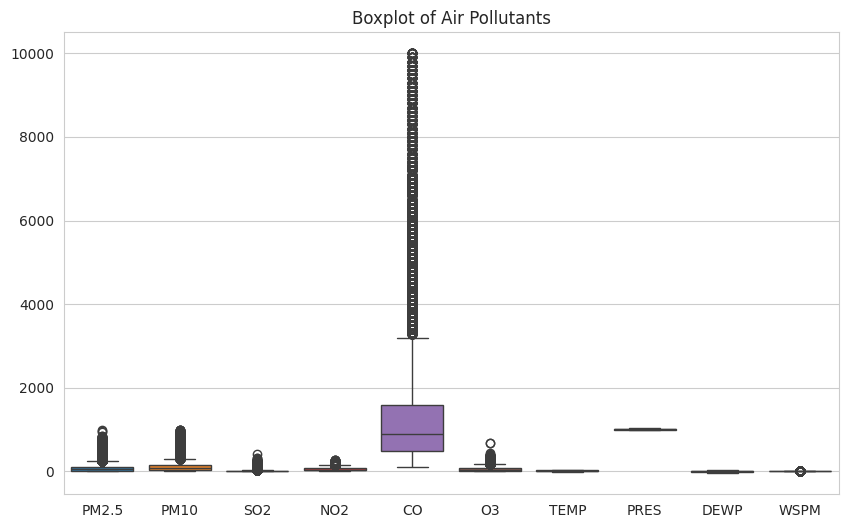

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=allData[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM']])
plt.title("Boxplot of Air Pollutants")
plt.show()

#### 5. Memeriksa Konsistensi Data Waktu

In [32]:
allData['datetime'] = pd.to_datetime(allData[['year', 'month', 'day', 'hour']])
print(allData['datetime'].min(), allData['datetime'].max())

2013-03-01 00:00:00 2017-02-28 23:00:00


#### 6. Pola Musiman dan Waktu

In [33]:
monthly_avg = allData.groupby('month')[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM']].mean()
print(monthly_avg)

            PM2.5        PM10        SO2        NO2           CO         O3  \
month                                                                         
1       96.481683  115.710001  30.859541  63.600142  1875.563031  26.126920   
2       89.316308  103.761257  27.907839  52.689900  1386.877395  39.519753   
3       95.685698  133.557385  28.351517  62.586884  1313.377604  49.110121   
4       72.541146  113.973676  14.666422  48.702487   861.696797  68.097529   
5       62.384428  104.882635  14.119669  43.919385   821.845334  90.354117   
6       70.161579   87.918630   8.128411  39.657329  1043.707285  92.847902   
7       72.494183   85.380751   5.687805  35.795083   930.200227  93.860783   
8       54.039719   71.809465   4.812429  36.335793   851.803508  84.694897   
9       61.504017   79.830274   6.665971  45.527206   952.223102  52.863065   
10      91.057420  111.657899   8.580451  59.089176  1153.294048  28.271454   
11      95.580509  120.088751  14.375526  61.545992 

**Insight:**

- Memberikan gambaran awal mengenai kemungkinan adanya pola musiman yang berkaitan dengan tingkat polutan udara..
- Membantu menentukan langkah analisis lanjutan yang lebih spesifik terkait musim atau waktu tertentu.

### Cleaning Data

In [45]:
for column in allData.select_dtypes(include=['number']).columns:
    allData[column].fillna(allData[column].mean(), inplace=True)

# Mengisi kolom kategorikal dengan nilai modus
for column in allData.select_dtypes(include=['object']).columns:
    allData[column].fillna(allData[column].mode()[0], inplace=True)

# Mengecek ulang apakah masih ada missing values
print(allData.isnull().sum())

/tmp/ipykernel_5192/2082058720.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  allData[column].fillna(allData[column].mean(), inplace=True)
/tmp/ipykernel_5192/2082058720.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

No          0
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64


#### Memperbaiki outlier

In [35]:
# Fungsi untuk mendeteksi dan menghapus outliers menggunakan IQR
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Menghapus data yang berada di luar lower_bound dan upper_bound
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Daftar kolom numerik yang akan diperiksa outliers
numeric_columns = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM']

# Menghapus outliers pada kolom yang dipilih
cleanedData = remove_outliers(allData, numeric_columns)

- IQR (Interquartile Range) digunakan untuk mendeteksi outliers. Data yang berada di luar rentang (Q1 - 1.5 * IQR) dan (Q3 + 1.5 * IQR) dianggap sebagai outliers dan dihapus.
- Kode di atas secara otomatis memproses setiap kolom numerik dalam daftar numeric_columns dan menghapus baris yang berisi outliers.

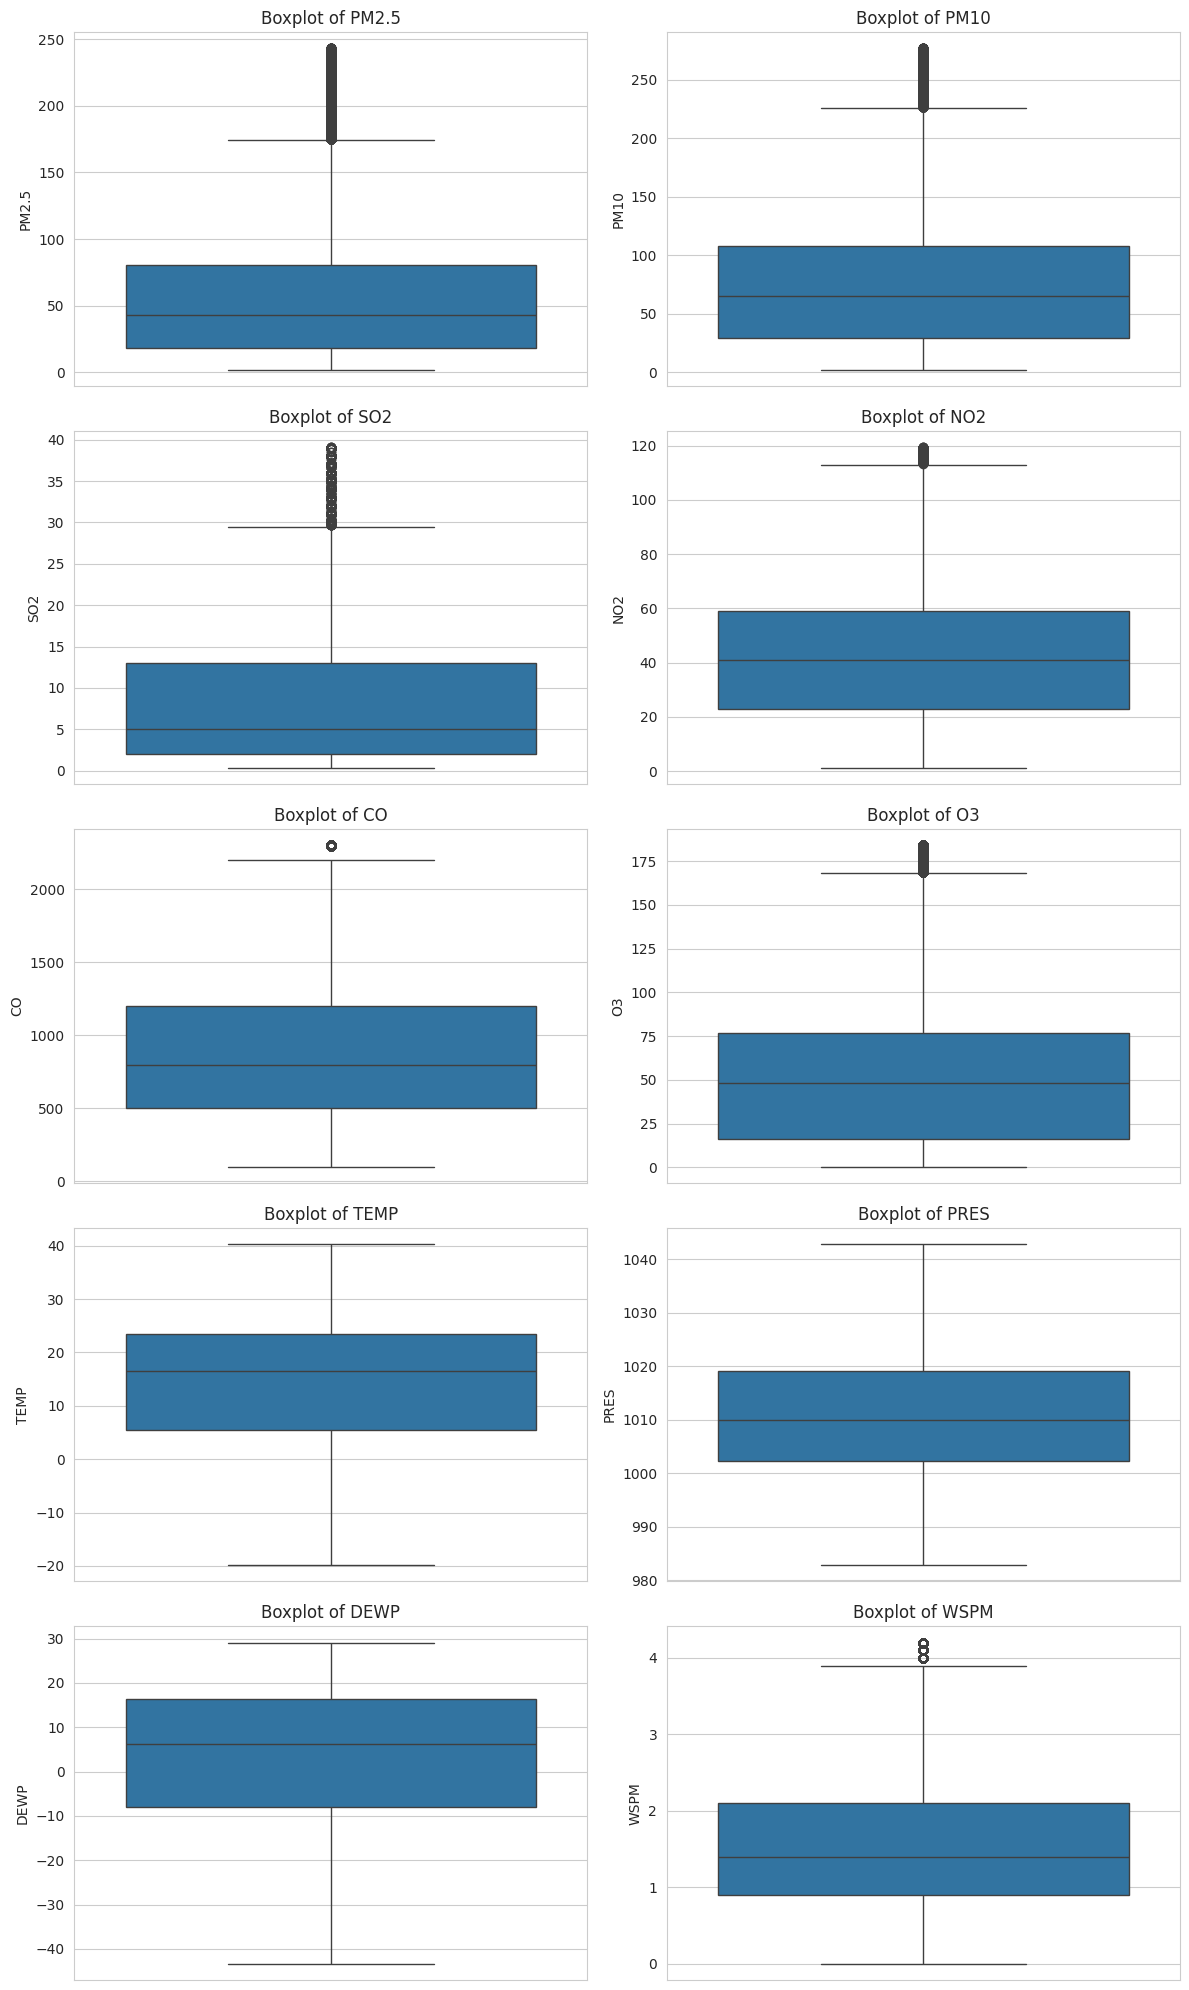

In [36]:
# Daftar kolom yang akan dipetakan
columns_to_plot = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM']

# Membuat figure dengan 2 kolom dan 5 baris
fig, ax = plt.subplots(5, 2, figsize=(12, 20))  # Ukuran diperbesar untuk menyesuaikan semua grafik

# Flatten axes untuk memudahkan iterasi
axes = ax.flatten()

# Looping untuk membuat boxplot pada setiap subplot
for i, column in enumerate(columns_to_plot):
    sns.boxplot(y=cleanedData[column], ax=axes[i])
    axes[i].set_title(f"Boxplot of {column}")

# Menyesuaikan tata letak agar lebih rapi
plt.tight_layout()
plt.show()

## Insight:

1. **Polutan Partikulat (PM2.5 dan PM10):**
   - **Distribusi Data:** Kedua polutan ini memiliki distribusi mayoritas pada level sedang (sekitar 50-100 µg/m³) namun terdapat outliers yang signifikan dengan konsentrasi lebih dari 200 µg/m³. Hal ini menunjukkan adanya momen atau lokasi dengan tingkat polusi udara yang berbahaya.
   - **Kesimpulan:** Polutan partikulat cenderung mengalami peningkatan ekstrem di waktu atau tempat tertentu, yang memerlukan perhatian khusus untuk mengidentifikasi penyebabnya.

2. **Polutan Gas (SO2, NO2, CO, O3):**
   - **SO2 dan NO2:** Distribusi cenderung terkonsentrasi dengan median rendah, namun terdapat outliers yang menunjukkan peningkatan konsentrasi signifikan pada waktu tertentu.
   - **CO:** Memiliki distribusi yang lebih luas dengan median sekitar 1000 µg/m³, menunjukkan adanya variasi besar dalam konsentrasinya, terutama akibat aktivitas manusia seperti pembakaran bahan bakar.
   - **O3:** Mayoritas data menunjukkan konsentrasi sedang (50-100 µg/m³), namun terdapat outliers yang signifikan, menunjukkan kemungkinan adanya reaksi fotokimia atau faktor lingkungan tertentu yang meningkatkan kadar ozon.

3. **Kondisi Cuaca (TEMP, PRES, DEWP, WSPM):**
   - **TEMP dan PRES:** Distribusi stabil tanpa banyak outliers, mencerminkan konsistensi suhu dan tekanan udara sepanjang periode pengamatan.
   - **DEWP:** Menunjukkan kondisi kelembaban yang konsisten dengan sedikit outliers, mengindikasikan bahwa kondisi ini relatif tidak berubah secara ekstrem.
   - **WSPM:** Sebagian besar data menunjukkan kecepatan angin rendah (1-2 m/s), dengan beberapa outliers di atas 4 m/s. Kecepatan angin yang rendah dapat menyebabkan akumulasi polutan di udara, memperburuk kualitas udara.

## Exploratory Data Analysis (EDA)

In [37]:
cleanedData.info()

<class 'pandas.core.frame.DataFrame'>
Index: 151141 entries, 0 to 210383
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        151141 non-null  int64         
 1   year      151141 non-null  int64         
 2   month     151141 non-null  int64         
 3   day       151141 non-null  int64         
 4   hour      151141 non-null  int64         
 5   PM2.5     151141 non-null  float64       
 6   PM10      151141 non-null  float64       
 7   SO2       151141 non-null  float64       
 8   NO2       151141 non-null  float64       
 9   CO        151141 non-null  float64       
 10  O3        151141 non-null  float64       
 11  TEMP      151141 non-null  float64       
 12  PRES      151141 non-null  float64       
 13  DEWP      151141 non-null  float64       
 14  RAIN      151141 non-null  float64       
 15  wd        151141 non-null  object        
 16  WSPM      151141 non-null  float64       
 

In [38]:
cleanedData.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
count,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.00000,151141.000000,151141.000000,151141,151141.000000,151141,151141
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,6,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Huairou,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17833,NaN,27590,NaN
mean,17971.473935,2014.699367,6.680047,15.839957,11.120748,55.752119,75.447792,8.962070,43.535914,877.316101,52.987572,14.578611,1010.79027,3.908972,0.074384,NaN,1.596555,NaN,2015-03-19 18:28:26.165765632
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.80000,-43.400000,0.000000,NaN,0.000000,NaN,2013-03-01 00:00:00
25%,9854.000000,2014.000000,4.000000,8.000000,5.000000,18.000000,29.000000,2.000000,23.000000,500.000000,16.000000,5.500000,1002.30000,-8.100000,0.000000,NaN,0.900000,NaN,2014-04-15 13:00:00
50%,18531.000000,2015.000000,7.000000,16.000000,11.000000,43.000000,65.000000,5.000000,41.000000,800.000000,48.000000,16.600000,1009.90000,6.300000,0.000000,NaN,1.400000,NaN,2015-04-12 02:00:00
75%,26938.000000,2016.000000,9.000000,23.000000,17.000000,80.774041,108.000000,13.000000,59.000000,1200.000000,77.000000,23.500000,1019.00000,16.400000,0.000000,NaN,2.100000,NaN,2016-03-27 09:00:00
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,243.000000,277.000000,39.127200,119.484600,2300.000000,184.000000,40.300000,1042.80000,29.100000,47.700000,NaN,4.200000,NaN,2017-02-28 23:00:00


## Insight:

- **Distribusi Polutan:** Dataset menunjukkan variasi konsentrasi yang signifikan untuk polutan utama seperti PM2.5, PM10, NO2, dan CO. Beberapa waktu mencatat konsentrasi polutan yang tinggi, mengindikasikan potensi dampak dari aktivitas manusia atau fenomena cuaca tertentu.

- **Kondisi Cuaca:** Parameter cuaca seperti suhu dan tekanan relatif stabil, namun terdapat variasi signifikan pada kelembaban dan curah hujan, yang dapat memengaruhi konsentrasi polutan di udara.

- **Cakupan Data:** Dataset mencakup periode waktu yang luas dari tahun 2013 hingga 2017, dengan pengukuran yang konsisten secara bulanan dan jam. Hal ini memberikan dasar yang baik untuk analisis temporal.

- **Kesiapan Analisis:** Dataset ini sudah siap untuk digunakan dalam analisis mendalam, termasuk:
  - **Analisis Musiman:** Mengidentifikasi pola polutan dan cuaca berdasarkan musim.
  - **Tren Waktu:** Melihat perubahan konsentrasi polutan dari waktu ke waktu.
  - **Korelasi Polutan dan Cuaca:** Menganalisis pengaruh kondisi cuaca terhadap distribusi dan konsentrasi polutan.


# Visualization & Explanatory Analysis

## Pertanyaan 1:

/tmp/ipykernel_5192/1253221437.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season', y='PM2.5', data=cleanedData, palette='Set3')
/tmp/ipykernel_5192/1253221437.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season', y='PM10', data=cleanedData, palette='Set3')


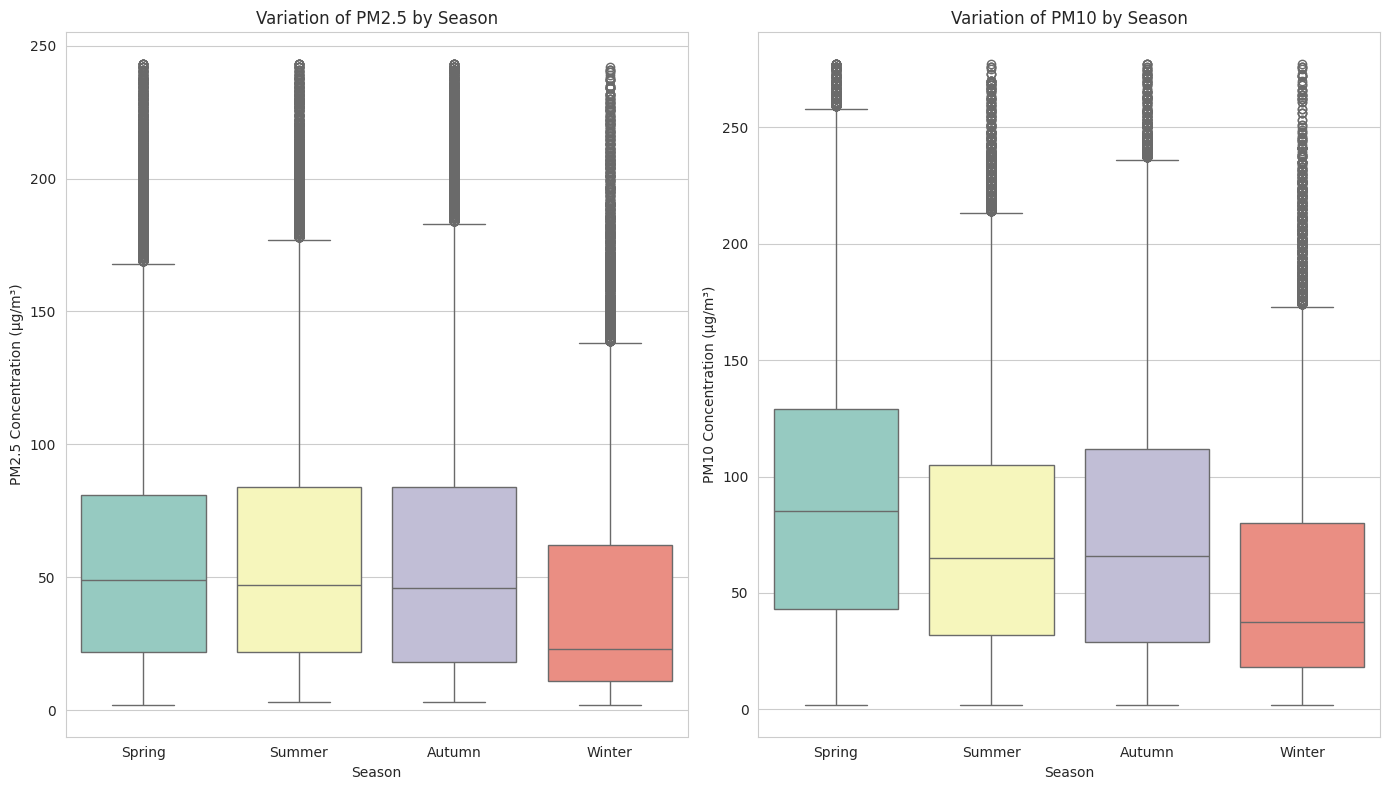

In [39]:
def get_season_data(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

# Ta column season pada dataframe
cleanedData['season'] = cleanedData['month'].apply(get_season_data)
plt.figure(figsize=(14, 8))

# Subplot PM2.5
plt.subplot(1, 2, 1)
sns.boxplot(x='season', y='PM2.5', data=cleanedData, palette='Set3')
plt.title('Variation of PM2.5 by Season')
plt.xlabel('Season')
plt.ylabel('PM2.5 Concentration (µg/m³)')

# Subplot PM10
plt.subplot(1, 2, 2)
sns.boxplot(x='season', y='PM10', data=cleanedData, palette='Set3')
plt.title('Variation of PM10 by Season')
plt.xlabel('Season')
plt.ylabel('PM10 Concentration (µg/m³)')
plt.tight_layout()
plt.show()

## Insight

1. **PM2.5 (Partikulat Halus):**
   - **Musim Dingin (Winter):** Konsentrasi PM2.5 sedikit lebih rendah dibandingkan musim lainnya, meskipun terdapat outliers yang menunjukkan tingkat polusi tinggi.
   - **Musim Semi, Panas, dan Gugur (Spring, Summer, Autumn):** Distribusi PM2.5 hampir serupa dengan median yang sedikit lebih tinggi dibandingkan musim dingin. Variasi antar musim tidak signifikan, namun outliers lebih banyak di musim ini, yang mungkin disebabkan oleh aktivitas manusia atau fenomena cuaca tertentu.

2. **PM10 (Partikulat Kasar):**
   - **Musim Dingin (Winter):** Distribusi PM10 lebih rendah dibandingkan musim lainnya, dengan median yang lebih rendah daripada musim semi dan gugur.
   - **Musim Semi dan Gugur (Spring, Autumn):** Distribusi lebih luas dengan median yang lebih tinggi, menunjukkan polusi partikel kasar lebih signifikan.
   - **Musim Panas (Summer):** Konsentrasi PM10 lebih rendah dibandingkan musim semi dan gugur, tetapi tetap lebih tinggi dibandingkan musim dingin. Outliers lebih sering terjadi di musim semi dan gugur, yang mungkin dipengaruhi oleh debu atau polutan tambahan dari aktivitas industri dan transportasi.

## Kesimpulan
- **Musim Dingin (Winter):** Memiliki kualitas udara yang sedikit lebih baik untuk PM2.5 dan PM10, meskipun masih ada outliers yang menunjukkan polusi di beberapa waktu atau lokasi tertentu.
- **Musim Semi dan Gugur (Spring, Autumn):** Menunjukkan kualitas udara yang lebih buruk, dengan konsentrasi partikel halus (PM2.5) dan kasar (PM10) yang lebih tinggi. Hal ini dapat disebabkan oleh aktivitas manusia, seperti pembakaran, atau pengaruh perubahan cuaca.
- **Musim Panas (Summer):** Kualitas udara lebih baik dibandingkan musim semi dan gugur, tetapi tetap lebih buruk daripada musim dingin.


## Pertanyaan 2:

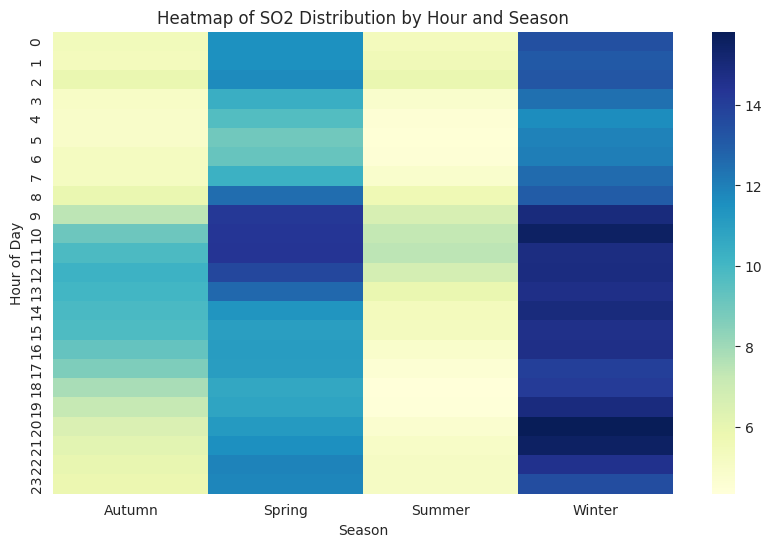

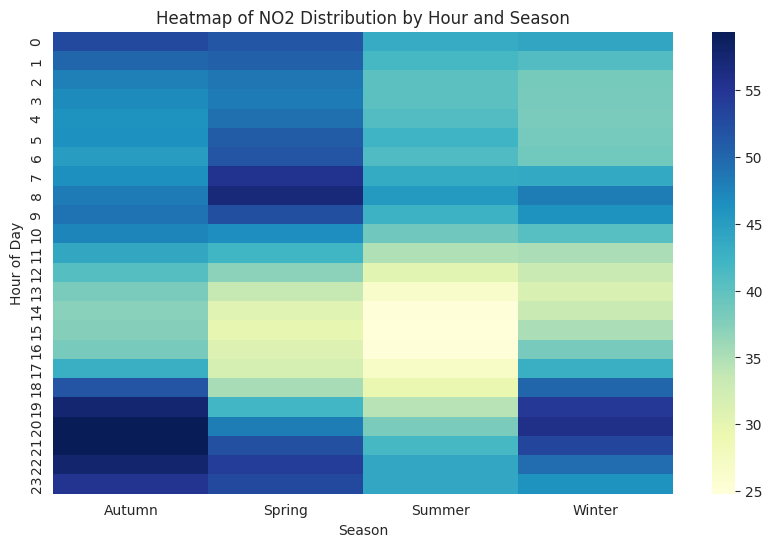

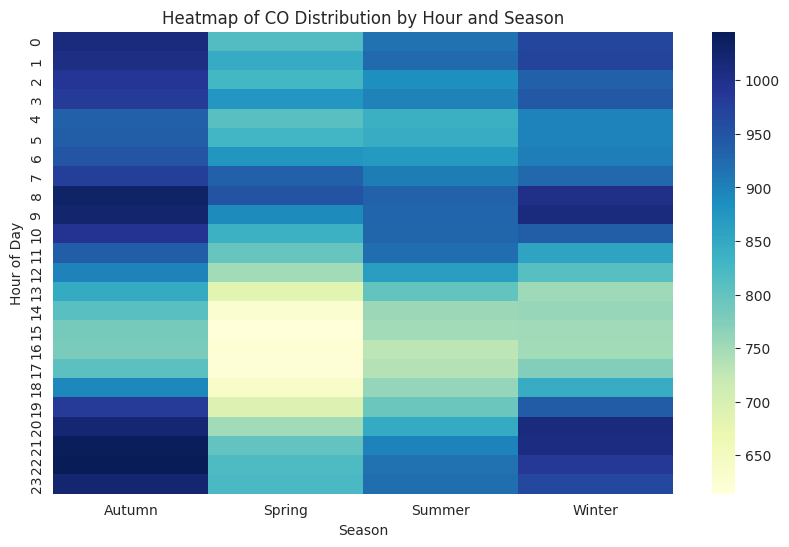

In [40]:
pivot_so2 = cleanedData.pivot_table(index='hour', columns='season', values='SO2', aggfunc='mean')

# Membuat heatmap SO2
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_so2, cmap="YlGnBu", annot=False)
plt.title('Heatmap of SO2 Distribution by Hour and Season')
plt.ylabel('Hour of Day')
plt.xlabel('Season')
plt.show()

# Membuat pivot NO2
pivot_no2 = cleanedData.pivot_table(index='hour', columns='season', values='NO2', aggfunc='mean')

# Membuat heatmap NO2
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_no2, cmap="YlGnBu", annot=False)
plt.title('Heatmap of NO2 Distribution by Hour and Season')
plt.ylabel('Hour of Day')
plt.xlabel('Season')
plt.show()

# Membuat pivot CO
pivot_co = cleanedData.pivot_table(index='hour', columns='season', values='CO', aggfunc='mean')

# Membuat heatmap CO
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_co, cmap="YlGnBu", annot=False)
plt.title('Heatmap of CO Distribution by Hour and Season')
plt.ylabel('Hour of Day')
plt.xlabel('Season')
plt.show()


## Insight

1. **Distribusi SO2 (Sulfur Dioksida):**
   - **Musim Dingin:** Konsentrasi SO2 lebih tinggi sepanjang hari, terutama pada malam hingga dini hari (18:00–09:00). Konsentrasi sedikit berkurang pada siang hari.
   - **Musim Semi dan Panas:** Konsentrasi SO2 lebih rendah dan stabil sepanjang hari, dengan tingkat polusi paling sedikit di musim panas.
   - **Musim Gugur:** Pola distribusi mirip dengan musim dingin, tetapi tingkat polusi tidak setinggi di musim dingin. Konsentrasi SO2 lebih tinggi pada malam hari.

2. **Distribusi NO2 (Nitrogen Dioksida):**
   - **Musim Dingin dan Gugur:** Konsentrasi NO2 lebih tinggi pada malam hari, terutama antara pukul 19:00 hingga 07:00, kemungkinan akibat peningkatan aktivitas seperti pemanasan dan kendaraan bermotor.
   - **Musim Panas dan Semi:** Konsentrasi lebih rendah dan relatif stabil sepanjang hari, menunjukkan penyebaran polusi yang lebih baik atau emisi yang lebih sedikit.

3. **Distribusi CO (Karbon Monoksida):**
   - **Musim Dingin:** Konsentrasi CO lebih tinggi di malam hari hingga dini hari (18:00–09:00), berkaitan dengan penggunaan pemanas dan pembakaran bahan bakar.
   - **Musim Semi dan Panas:** Konsentrasi lebih rendah dan stabil sepanjang hari, dengan tingkat polusi paling sedikit di musim panas.
   - **Musim Gugur:** Pola distribusi serupa dengan musim dingin, dengan konsentrasi lebih tinggi pada malam hingga pagi hari.

## Kesimpulan
- **Polutan Malam Hari:** SO2, NO2, dan CO cenderung menunjukkan konsentrasi tertinggi pada malam hingga dini hari, terutama di musim dingin dan gugur, akibat aktivitas manusia seperti pemanasan, kendaraan, dan pembakaran bahan bakar.
- **Musim Panas dan Semi:** Konsentrasi polutan lebih rendah dan stabil, terutama di siang hari, kemungkinan karena penyebaran polusi yang lebih cepat akibat kondisi cuaca yang mendukung.
- **Musim Dingin:** Konsentrasi polutan lebih tinggi secara konsisten, yang kemungkinan dipengaruhi oleh efek inversi suhu, yang menjebak polutan di dekat permukaan tanah saat cuaca dingin.


## Pertanyaan 3:

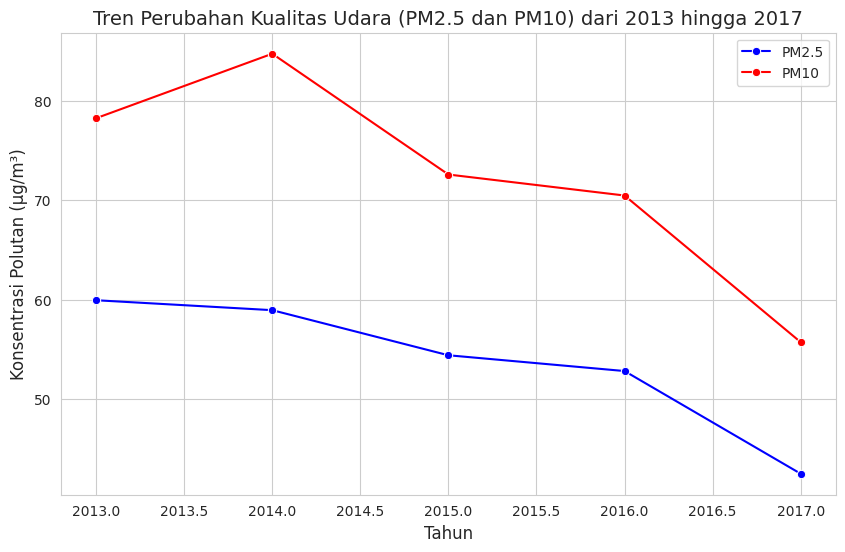

In [41]:
if 'datetime' not in cleanedData.columns:
    cleanedData['datetime'] = pd.to_datetime(
        cleanedData[['year', 'month', 'day', 'hour']]
    )

# Mengelompokkan data berdasarkan tahun dan menghitung rata-rata PM2.5 dan PM10 per tahun
yearly_avg = cleanedData.groupby(cleanedData['datetime'].dt.year)[['PM2.5', 'PM10']].mean().reset_index()

# Membuat figure untuk line plot
plt.figure(figsize=(10, 6))

# Plot tren PM2.5
sns.lineplot(x='datetime', y='PM2.5', data=yearly_avg, marker='o', label='PM2.5', color='b')

# Plot tren PM10
sns.lineplot(x='datetime', y='PM10', data=yearly_avg, marker='o', label='PM10', color='r')

plt.title('Tren Perubahan Kualitas Udara (PM2.5 dan PM10) dari 2013 hingga 2017', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Konsentrasi Polutan (µg/m³)', fontsize=12)

# add legend
plt.legend()
plt.show()

## Insight

1. **PM2.5 (Partikulat Halus):**
   - Pada tahun 2013, konsentrasi PM2.5 berada di sekitar 60 µg/m³.
   - Setelah tahun 2014, konsentrasi PM2.5 mulai menurun secara konsisten. Penurunan yang cukup signifikan terlihat antara tahun 2016 dan 2017, dengan konsentrasi mencapai sekitar 45 µg/m³ pada tahun 2017, lebih rendah dibandingkan tahun-tahun sebelumnya.
   - **Tren Penurunan:** Secara keseluruhan, konsentrasi PM2.5 menurun dari tahun 2013 hingga 2017, mencerminkan peningkatan kualitas udara terkait partikulat halus.

2. **PM10 (Partikulat Kasar):**
   - Pada tahun 2013, konsentrasi PM10 tercatat sekitar 75 µg/m³.
   - Tahun 2014 terjadi peningkatan konsentrasi hingga sekitar 85 µg/m³, tetapi mulai menurun perlahan setelahnya. Penurunan tajam terjadi antara tahun 2016 dan 2017, di mana konsentrasi PM10 turun menjadi sekitar 65 µg/m³.
   - **Tren Penurunan:** Seperti PM2.5, konsentrasi PM10 juga menunjukkan tren penurunan sejak puncaknya pada tahun 2014 hingga 2017, menunjukkan peningkatan kualitas udara terkait partikulat kasar.

## Kesimpulan
- Secara keseluruhan, kualitas udara mengalami perbaikan dari tahun 2013 hingga 2017, yang ditandai dengan penurunan konsentrasi PM2.5 dan PM10. Perbaikan ini kemungkinan dipengaruhi oleh penerapan kebijakan lingkungan yang lebih ketat atau perubahan aktivitas industri dan transportasi.
- Tren yang sama terlihat pada PM2.5 dan PM10, dengan penurunan signifikan setelah tahun 2014, terutama pada tahun 2017.


## Pertanyaan 4:

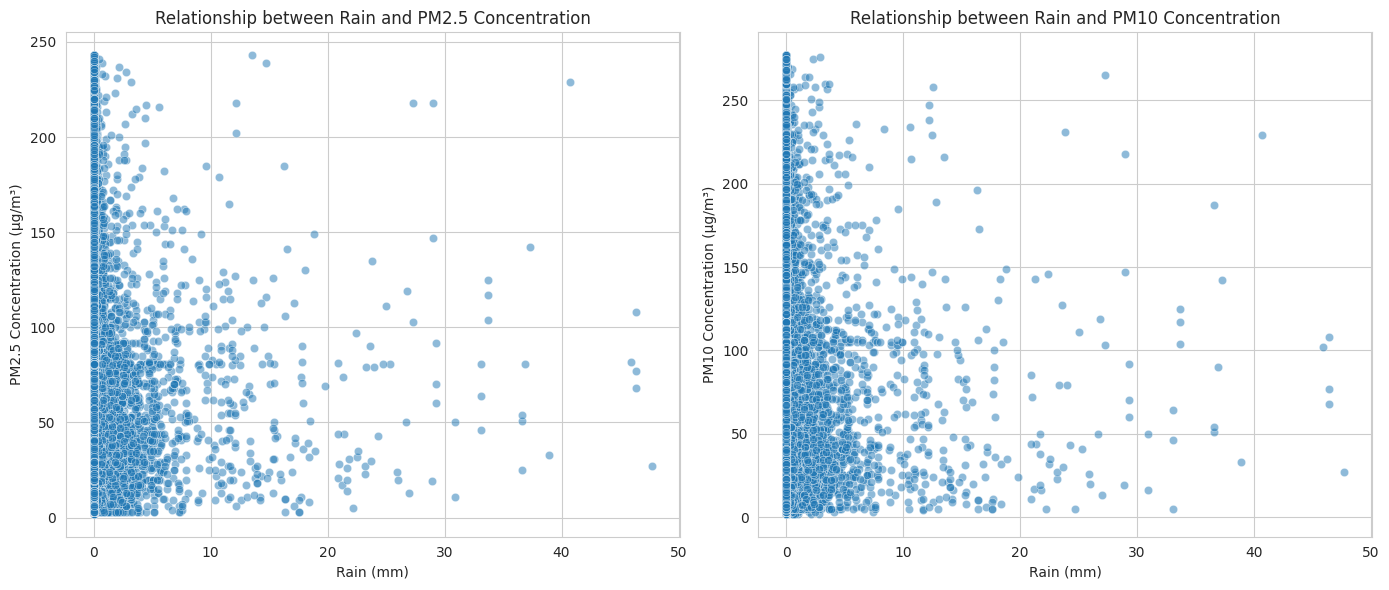

In [42]:
plt.figure(figsize=(14, 6))

# Subplot PM2.5 vs RAIN
plt.subplot(1, 2, 1)
sns.scatterplot(x='RAIN', y='PM2.5', data=cleanedData, alpha=0.5)
plt.title('Relationship between Rain and PM2.5 Concentration')
plt.xlabel('Rain (mm)')
plt.ylabel('PM2.5 Concentration (µg/m³)')

# Subplot PM10 vs RAIN
plt.subplot(1, 2, 2)
sns.scatterplot(x='RAIN', y='PM10', data=cleanedData, alpha=0.5)
plt.title('Relationship between Rain and PM10 Concentration')
plt.xlabel('Rain (mm)')
plt.ylabel('PM10 Concentration (µg/m³)')

plt.tight_layout()
plt.show()

## Insight

1. **Pengaruh Curah Hujan terhadap PM2.5:**
   - **Kondisi Tanpa Hujan:** Pada curah hujan 0 mm, konsentrasi PM2.5 sangat bervariasi, mulai dari rendah hingga sangat tinggi (>200 µg/m³).
   - **Penurunan dengan Hujan:** Ketika curah hujan melebihi 0 mm, konsentrasi PM2.5 secara bertahap menurun. Pada curah hujan yang lebih tinggi (≥10 mm), konsentrasi PM2.5 umumnya berada di level yang lebih rendah.
   - **Kesimpulan:** Curah hujan berperan sebagai mekanisme pembersihan udara, secara efektif mengurangi konsentrasi PM2.5 di atmosfer.

2. **Pengaruh Curah Hujan terhadap PM10:**
   - **Kondisi Tanpa Hujan:** Mirip dengan PM2.5, konsentrasi PM10 pada curah hujan 0 mm menunjukkan variasi besar, dengan beberapa data mencatat nilai sangat tinggi (>250 µg/m³).
   - **Penurunan dengan Hujan:** Peningkatan curah hujan menunjukkan tren penurunan konsentrasi PM10, meskipun penurunan ini lebih lambat dibandingkan PM2.5. Bahkan pada curah hujan tinggi (>20 mm), masih ditemukan beberapa titik dengan konsentrasi PM10 yang cukup tinggi.
   - **Kesimpulan:** Curah hujan juga membantu mengurangi konsentrasi PM10, tetapi efeknya cenderung lebih lemah dibandingkan pada PM2.5. Polutan yang lebih besar seperti PM10 membutuhkan curah hujan yang lebih tinggi untuk efektif tereliminasi.

## Kesimpulan
- Curah hujan berdampak positif dalam mengurangi polutan udara, terutama PM2.5 dan PM10. Konsentrasi polutan cenderung menurun seiring meningkatnya curah hujan, karena hujan membantu menyapu partikel polutan dari atmosfer.
- PM2.5 menunjukkan penurunan yang lebih cepat dibandingkan PM10, kemungkinan karena ukurannya yang lebih kecil sehingga lebih mudah tersapu oleh air hujan.
- Dampak hujan menjadi lebih signifikan pada curah hujan di atas 10 mm, dengan konsentrasi polutan yang lebih stabil pada tingkat rendah.


In [43]:
cleanedData = cleanedData.drop(columns=['No'])

In [44]:
cleanedData.to_csv("./dashboard/main-data.csv", index=False)